<a href="https://colab.research.google.com/github/cl0udy322322-crypto/project3/blob/main/momentum_strategy_cooldown1week(%EC%A0%84%EB%B6%801%EC%A3%BC).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실전 모멘텀 전략 백테스트 (쿨다운 1주 버전)

## 주요 설정
1. **쿨다운 기간**: 1주 (빠른 회전)
2. **백테스트 기간**: 2015.01.01 ~ 2025.12.30 (10년)
3. **주단위 리밸런싱**: 매주 금요일
4. **Look-ahead Bias 방지**: 전일 종가 기준 신호 생성
5. **실행가격**: 다음 영업일 시가 체결

In [ ]:
# =====================================================
# [STEP 0] 라이브러리 설치 및 불러오기
# =====================================================
!pip install -q yfinance pandas numpy ta tqdm matplotlib seaborn

import yfinance as yf
import pandas as pd
import numpy as np
import ta
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 폰트 설정 (한글 지원)
try:
    plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
except:
    try:
        plt.rcParams['font.family'] = 'AppleGothic'  # Mac
    except:
        plt.rcParams['font.family'] = 'DejaVu Sans'  # Linux/Colab

plt.rcParams['axes.unicode_minus'] = False
plt.style.use("seaborn-v0_8-darkgrid")

print("라이브러리 로드 완료")

  Preparing metadata (setup.py) ... done
라이브러리 로드 완료


In [ ]:
# =====================================================
# [STEP 1] 기본 파라미터 설정
# =====================================================

# 백테스트 기간 (10년)
INITIAL_CAPITAL = 100_000_000  # 초기 자본 (1억원)
START_DATE = "2015-01-01"
END_DATE = "2025-12-30"

# 전략 파라미터
N_STOCKS = 8                # 보유 종목 수
COOLDOWN_WEEKS = 1          # 최소 보유 기간 (1주) ⚡ 빠른 회전
MOMENTUM_LOOKBACK = 252     # 모멘텀 측정 기간 (12개월)
MOMENTUM_SKIP = 21          # 최근 제외 기간 (1개월)
EMA_PERIOD = 200            # 시장 필터 EMA 기간

# 비용 설정
COMMISSION_RATE = 0.00015   # 증권사 수수료 (0.015%)
TAX_RATE = 0.0023           # 거래세 (0.23%, 매도시만)
SLIPPAGE_RATE = 0.001       # 슬리피지 (0.1%)
TOTAL_COST_BUY = COMMISSION_RATE + SLIPPAGE_RATE    # 매수 비용
TOTAL_COST_SELL = COMMISSION_RATE + TAX_RATE + SLIPPAGE_RATE  # 매도 비용

print("="*60)
print("전략 파라미터 설정 완료")
print("="*60)
print(f"초기 자본: {INITIAL_CAPITAL:,}원")
print(f"백테스트 기간: {START_DATE} ~ {END_DATE} (10년)")
print(f"보유 종목 수: {N_STOCKS}개")
print(f"⚡ 쿨다운 기간: {COOLDOWN_WEEKS}주 (빠른 회전 전략)")
print(f"리밸런싱: 매주 금요일 (전일 종가 기준 신호 생성)")
print(f"매수 비용: {TOTAL_COST_BUY*100:.3f}%")
print(f"매도 비용: {TOTAL_COST_SELL*100:.3f}%")
print("="*60)

전략 파라미터 설정 완료
초기 자본: 100,000,000원
백테스트 기간: 2015-01-01 ~ 2025-12-30 (10년)
보유 종목 수: 8개
⚡ 쿨다운 기간: 1주 (빠른 회전 전략)
리밸런싱: 매주 금요일 (전일 종가 기준 신호 생성)
매수 비용: 0.115%
매도 비용: 0.345%


In [ ]:
# =====================================================
# [STEP 2] 데이터 다운로드
# =====================================================

print("\n" + "="*60)
print("데이터 다운로드 시작")
print("="*60)

# 1. KOSPI 지수 다운로드
print("\n[1/3] KOSPI 지수 데이터 다운로드 중...")
kospi_raw = yf.download("^KS11", start=START_DATE, end=END_DATE,
                        progress=False, auto_adjust=True)

if isinstance(kospi_raw.columns, pd.MultiIndex):
    kospi_raw.columns = kospi_raw.columns.get_level_values(0)

kospi = kospi_raw.copy()
kospi['EMA200'] = ta.trend.ema_indicator(kospi['Close'], window=EMA_PERIOD)
kospi = kospi.dropna(subset=['EMA200'])

print(f"✓ KOSPI 데이터: {len(kospi)}일")

# 2. 종목 티커 로드
print("\n[2/3] 종목 리스트 로드 중...")

# CSV 파일 경로 탐색
csv_candidates = [
    "코스피 지수 200종목.csv",
    "kospi200.csv",
    "tickers.csv",
    "/content/코스피 지수 200종목.csv"
]

tickers = None
for csv_path in csv_candidates:
    if os.path.exists(csv_path):
        try:
            df_raw = pd.read_csv(csv_path, encoding="cp949", dtype=str)
            # 가능한 컬럼명 탐색
            possible_cols = ["Ticker", "종목코드", "Code", "Symbol", "ticker", "code"]
            col = next((c for c in possible_cols if c in df_raw.columns), None)

            if col:
                tickers = [f"{str(t).strip().zfill(6)}.KS" for t in df_raw[col]]
                print(f"✓ CSV 로드 성공: {csv_path}")
                print(f"✓ 종목 수: {len(tickers)}개")
                break
        except Exception as e:
            print(f"  {csv_path} 로드 실패: {e}")
            continue

# CSV 로드 실패 시 기본 종목 사용
if tickers is None:
    print("⚠ CSV 파일을 찾을 수 없습니다. 기본 종목 리스트를 사용합니다.")
    tickers = [
        "005930.KS",  # 삼성전자
        "000660.KS",  # SK하이닉스
        "035420.KS",  # NAVER
        "005380.KS",  # 현대차
        "035720.KS",  # 카카오
        "051910.KS",  # LG화학
        "000270.KS",  # 기아
        "068270.KS",  # 셀트리온
        "006400.KS",  # 삼성SDI
        "105560.KS",  # KB금융
        "055550.KS",  # 신한지주
        "012330.KS",  # 현대모비스
        "028260.KS",  # 삼성물산
        "066570.KS",  # LG전자
        "003550.KS",  # LG
        "096770.KS",  # SK이노베이션
        "017670.KS",  # SK텔레콤
        "009150.KS",  # 삼성전기
        "034730.KS",  # SK
        "018260.KS",  # 삼성에스디에스
    ]
    print(f"✓ 기본 종목 수: {len(tickers)}개")

# 3. 개별 종목 데이터 다운로드
print("\n[3/3] 개별 종목 데이터 다운로드 중...")
print("(약 1-3분 소요될 수 있습니다)\n")

stocks = {}
failed_tickers = []

for ticker in tqdm(tickers, desc="다운로드 진행",
                   bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{percentage:3.0f}%]'):
    try:
        df = yf.download(ticker, start=START_DATE, end=END_DATE,
                        progress=False, auto_adjust=True)

        # 최소 데이터 요구사항 체크 (1년 이상)
        if len(df) < 260:
            failed_tickers.append(ticker)
            continue

        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # Look-ahead Bias 방지: 전일 데이터를 사용하여 모멘텀 계산
        df['Close_Lag1'] = df['Close'].shift(1)  # 전일 종가

        # 12-1 모멘텀: 전일 기준 (Look-ahead 방지)
        df['Momentum'] = (df['Close_Lag1'].shift(MOMENTUM_SKIP) /
                         df['Close_Lag1'].shift(MOMENTUM_LOOKBACK) - 1)

        # 결측치 제거
        df = df.dropna(subset=['Momentum', 'Close_Lag1'])

        if len(df) > 0:
            stocks[ticker] = df
        else:
            failed_tickers.append(ticker)

    except Exception as e:
        failed_tickers.append(ticker)
        continue

print("\n" + "="*60)
print(f"데이터 다운로드 완료")
print("="*60)
print(f"✓ 분석 가능 종목: {len(stocks)}개")
if failed_tickers:
    print(f"✗ 실패한 종목: {len(failed_tickers)}개")
print("="*60)


데이터 다운로드 시작

[1/3] KOSPI 지수 데이터 다운로드 중...
✓ KOSPI 데이터: 2496일

[2/3] 종목 리스트 로드 중...
✓ CSV 로드 성공: 코스피 지수 200종목.csv
✓ 종목 수: 200개

[3/3] 개별 종목 데이터 다운로드 중...
(약 1-3분 소요될 수 있습니다)



다운로드 진행: 100%|██████████| 200/200 [100%]


데이터 다운로드 완료
✓ 분석 가능 종목: 198개
✗ 실패한 종목: 2개


In [ ]:
# =====================================================
# [STEP 3] 주단위 리밸런싱 날짜 생성
# =====================================================

print("\n주단위 리밸런싱 스케줄 생성 중...")

# 매주 금요일을 리밸런싱 날짜로 설정
all_dates = kospi.index

# 금요일 찾기 (weekday: 0=월요일, 4=금요일)
fridays = all_dates[all_dates.weekday == 4]

# 월말이 금요일이 아닌 경우를 대비하여 월말도 포함
month_ends = all_dates.to_period('M').to_timestamp('M')
month_ends = all_dates[all_dates.isin(month_ends)]

# 금요일과 월말을 합치고 정렬
rebalance_dates = pd.DatetimeIndex(sorted(set(fridays) | set(month_ends)))

# EMA200이 계산된 날짜부터 시작
rebalance_dates = rebalance_dates[rebalance_dates >= kospi.index[0]]

print(f"✓ 총 리밸런싱 횟수: {len(rebalance_dates)}회")
print(f"✓ 평균 리밸런싱 주기: {(rebalance_dates[-1] - rebalance_dates[0]).days / len(rebalance_dates):.1f}일")
print(f"✓ 첫 리밸런싱: {rebalance_dates[0].strftime('%Y-%m-%d')}")
print(f"✓ 마지막 리밸런싱: {rebalance_dates[-1].strftime('%Y-%m-%d')}")


주단위 리밸런싱 스케줄 생성 중...
✓ 총 리밸런싱 횟수: 563회
✓ 평균 리밸런싱 주기: 6.6일
✓ 첫 리밸런싱: 2015-10-23
✓ 마지막 리밸런싱: 2025-12-26


In [ ]:
# =====================================================
# [STEP 4] 백테스트 핵심 함수 정의
# =====================================================

def get_market_regime(date):
    """
    시장 국면 판별 (Look-ahead Bias 방지)
    - 전일 종가 기준으로 판단
    """
    try:
        # 해당 날짜의 전일 데이터 사용
        idx = kospi.index.get_indexer([date], method='pad')[0]
        if idx < 1:  # 최소 1일 이전 데이터 필요
            return 'OFF'

        # 전일 종가와 EMA 사용
        prev_close = kospi.iloc[idx-1]['Close']
        prev_ema = kospi.iloc[idx-1]['EMA200']

        if pd.isna(prev_ema):
            return 'OFF'

        # 시장 국면 판별
        if prev_close < prev_ema * 0.97:
            return 'OFF'  # 하락장
        elif prev_close < prev_ema:
            return 'REDUCE'  # 조정장
        else:
            return 'ON'  # 상승장

    except:
        return 'OFF'


def get_execution_price(ticker, signal_date, price_type='Open'):
    """
    실행 가격 조회 (Look-ahead Bias 방지)
    - signal_date: 신호 생성 날짜 (금요일 종가 기준)
    - 실제 매매는 다음 영업일 시가에 체결
    """
    try:
        df = stocks[ticker]

        # signal_date 이후 첫 영업일 찾기
        future_dates = df.index[df.index > signal_date]
        if len(future_dates) == 0:
            return None

        exec_date = future_dates[0]  # 다음 영업일

        # 시가로 체결 (실전 반영)
        if price_type == 'Open' and exec_date in df.index:
            return df.loc[exec_date, 'Open']
        elif exec_date in df.index:
            return df.loc[exec_date, 'Close']

        return None

    except:
        return None


def get_current_price(ticker, date):
    """
    평가 가격 조회 (포트폴리오 평가용)
    - 해당 날짜의 종가 사용
    """
    try:
        df = stocks[ticker]
        if date in df.index:
            return df.loc[date, 'Close']

        # 과거 데이터 중 가장 최근 가격
        past_data = df[df.index <= date]
        if len(past_data) > 0:
            return past_data['Close'].iloc[-1]

        return None
    except:
        return None

print("백테스트 함수 정의 완료")

백테스트 함수 정의 완료


In [ ]:
# =====================================================
# [STEP 5] 백테스트 실행
# =====================================================

print("\n" + "="*60)
print("백테스트 시작")
print("="*60)

# 초기화
cash = INITIAL_CAPITAL
holdings = {}  # {ticker: {'shares': int, 'buy_date': Timestamp, 'buy_price': float}}
history = []   # [(date, total_value, cash, regime, num_holdings)]
trades = []    # [(date, ticker, action, shares, price, cost)]

total_buy_value = 0
total_sell_value = 0

# 메인 백테스트 루프
for i, signal_date in enumerate(tqdm(rebalance_dates, desc="백테스트 진행")):

    # 1. 포트폴리오 평가 (당일 종가 기준)
    portfolio_value = cash
    holdings_to_remove = []

    for ticker, info in holdings.items():
        price = get_current_price(ticker, signal_date)
        if price is not None:
            portfolio_value += info['shares'] * price
        else:
            holdings_to_remove.append(ticker)

    # 상장폐지된 종목 제거
    for ticker in holdings_to_remove:
        del holdings[ticker]

    # 2. 시장 국면 판별 (전일 데이터 기준)
    regime = get_market_regime(signal_date)

    # 3. 하락장(OFF): 전량 청산
    if regime == 'OFF':
        for ticker in list(holdings.keys()):
            info = holdings[ticker]
            exec_price = get_execution_price(ticker, signal_date)

            if exec_price is not None:
                # 매도 체결
                sell_value = info['shares'] * exec_price
                cost = sell_value * TOTAL_COST_SELL
                proceeds = sell_value - cost

                cash += proceeds
                total_sell_value += sell_value

                trades.append({
                    'date': signal_date,
                    'ticker': ticker,
                    'action': 'SELL',
                    'shares': info['shares'],
                    'price': exec_price,
                    'cost': cost
                })

                del holdings[ticker]

        history.append({
            'date': signal_date,
            'total_value': cash,
            'cash': cash,
            'regime': regime,
            'num_holdings': 0
        })
        continue

    # 4. 투자 가능 종목 선별 및 랭킹 (전일 데이터 기준)
    available_stocks = []
    for ticker, df in stocks.items():
        if signal_date in df.index:
            momentum = df.loc[signal_date, 'Momentum']
            if not pd.isna(momentum):
                available_stocks.append((ticker, momentum))

    # 모멘텀 상위 종목 선별
    available_stocks.sort(key=lambda x: x[1], reverse=True)
    ranked_tickers = [t for t, _ in available_stocks]

    # 5. 쿨다운 체크 (최소 보유 기간) - 1주
    cooldown_tickers = []
    for ticker, info in holdings.items():
        weeks_held = (signal_date - info['buy_date']).days / 7
        if weeks_held < COOLDOWN_WEEKS:
            cooldown_tickers.append(ticker)

    # 6. 목표 포트폴리오 구성
    target_tickers = cooldown_tickers.copy()

    # 상승장(ON): N개 전부 투자
    # 조정장(REDUCE): N*0.6 = 약 5개 투자
    target_count = N_STOCKS if regime == 'ON' else max(1, int(N_STOCKS * 0.6))

    for ticker in ranked_tickers:
        if len(target_tickers) >= target_count:
            break
        if ticker not in target_tickers:
            target_tickers.append(ticker)

    # 7. 리밸런싱 - 매도
    for ticker in list(holdings.keys()):
        if ticker not in target_tickers:
            info = holdings[ticker]
            exec_price = get_execution_price(ticker, signal_date)

            if exec_price is not None:
                sell_value = info['shares'] * exec_price
                cost = sell_value * TOTAL_COST_SELL
                proceeds = sell_value - cost

                cash += proceeds
                total_sell_value += sell_value

                trades.append({
                    'date': signal_date,
                    'ticker': ticker,
                    'action': 'SELL',
                    'shares': info['shares'],
                    'price': exec_price,
                    'cost': cost
                })

                del holdings[ticker]

    # 8. 리밸런싱 - 매수
    if len(target_tickers) > 0 and cash > 0:
        target_weight = 1.0 / len(target_tickers)

        for ticker in target_tickers:
            if ticker not in holdings:
                exec_price = get_execution_price(ticker, signal_date)

                if exec_price is not None and exec_price > 0:
                    # 목표 투자금액
                    target_cash = portfolio_value * target_weight

                    # 매수 가능 주식 수
                    shares = int((target_cash / exec_price) / (1 + TOTAL_COST_BUY))

                    if shares > 0:
                        buy_value = shares * exec_price
                        cost = buy_value * TOTAL_COST_BUY
                        total_cost = buy_value + cost

                        if total_cost <= cash:
                            cash -= total_cost
                            total_buy_value += buy_value

                            holdings[ticker] = {
                                'shares': shares,
                                'buy_date': signal_date,
                                'buy_price': exec_price
                            }

                            trades.append({
                                'date': signal_date,
                                'ticker': ticker,
                                'action': 'BUY',
                                'shares': shares,
                                'price': exec_price,
                                'cost': cost
                            })

    # 9. 포트폴리오 재평가
    portfolio_value = cash
    for ticker, info in holdings.items():
        price = get_current_price(ticker, signal_date)
        if price is not None:
            portfolio_value += info['shares'] * price

    history.append({
        'date': signal_date,
        'total_value': portfolio_value,
        'cash': cash,
        'regime': regime,
        'num_holdings': len(holdings)
    })

print("\n" + "="*60)
print("백테스트 완료")
print("="*60)


백테스트 시작


백테스트 진행: 100%|██████████| 563/563 [00:02<00:00, 223.86it/s]


백테스트 완료


In [ ]:
# =====================================================
# [STEP 6] 결과 분석 및 시각화
# =====================================================

# DataFrame 변환
df_history = pd.DataFrame(history).set_index('date')
df_trades = pd.DataFrame(trades)

# 수익률 계산
df_history['returns'] = df_history['total_value'].pct_change()
df_history['cum_returns'] = (1 + df_history['returns']).cumprod()
df_history['drawdown'] = (df_history['total_value'] /
                          df_history['total_value'].cummax() - 1)

# 핵심 성과지표 계산
final_value = df_history['total_value'].iloc[-1]
total_return = (final_value / INITIAL_CAPITAL - 1) * 100
years = (df_history.index[-1] - df_history.index[0]).days / 365.25
cagr = (final_value / INITIAL_CAPITAL) ** (1 / years) - 1
mdd = df_history['drawdown'].min() * 100

# 샤프 비율 (주간 수익률 기준)
weekly_returns = df_history['returns'].dropna()
sharpe = (weekly_returns.mean() / weekly_returns.std()) * np.sqrt(52) if len(weekly_returns) > 0 else 0

# 승률
win_rate = (weekly_returns > 0).sum() / len(weekly_returns) * 100 if len(weekly_returns) > 0 else 0

# 회전율
turnover = (total_buy_value + total_sell_value) / 2 / years / INITIAL_CAPITAL * 100

# 결과 출력
print("\n" + "="*60)
print("⚡ 최종 성과 요약 (쿨다운 1주)")
print("="*60)
print(f"백테스트 기간: {df_history.index[0].strftime('%Y-%m-%d')} ~ {df_history.index[-1].strftime('%Y-%m-%d')}")
print(f"운용 기간: {years:.2f}년")
print("\n자산 변화:")
print(f"  초기 자본: {INITIAL_CAPITAL:,.0f}원")
print(f"  최종 자산: {final_value:,.0f}원")
print(f"  누적 수익: {final_value - INITIAL_CAPITAL:,.0f}원")
print("\n수익률 지표:")
print(f"  누적 수익률: {total_return:,.2f}%")
print(f"  연평균 수익률 (CAGR): {cagr*100:.2f}%")
print(f"  최대 낙폭 (MDD): {mdd:.2f}%")
print(f"  샤프 비율: {sharpe:.2f}")
print(f"  주간 승률: {win_rate:.2f}%")
print("\n거래 통계:")
print(f"  연간 회전율: {turnover:.2f}%")
print(f"  총 거래 횟수: {len(df_trades)}회")
print(f"  매수 거래: {len(df_trades[df_trades['action']=='BUY'])}회")
print(f"  매도 거래: {len(df_trades[df_trades['action']=='SELL'])}회")
print(f"  총 거래 비용: {df_trades['cost'].sum():,.0f}원")
print("="*60)

# 연도별 수익률
df_history['year'] = df_history.index.year
yearly_returns = df_history.groupby('year')['total_value'].agg(['first', 'last'])
yearly_returns['return'] = (yearly_returns['last'] / yearly_returns['first'] - 1) * 100

print("\n연도별 수익률:")
for year, ret in yearly_returns['return'].items():
    print(f"  {year}년: {ret:>7.2f}%")
print("="*60)


⚡ 최종 성과 요약 (쿨다운 1주)
백테스트 기간: 2015-10-23 ~ 2025-12-26
운용 기간: 10.18년

자산 변화:
  초기 자본: 100,000,000원
  최종 자산: 178,898,693원
  누적 수익: 78,898,693원

수익률 지표:
  누적 수익률: 78.90%
  연평균 수익률 (CAGR): 5.88%
  최대 낙폭 (MDD): -45.03%
  샤프 비율: 0.33
  주간 승률: 38.97%

거래 통계:
  연간 회전율: 663.03%
  총 거래 횟수: 680회
  매수 거래: 344회
  매도 거래: 336회
  총 거래 비용: 30,960,499원

연도별 수익률:
  2015년:    0.00%
  2016년:  -18.88%
  2017년:   37.34%
  2018년:  -11.30%
  2019년:   -9.12%
  2020년:    5.14%
  2021년:  -13.41%
  2022년:  -12.84%
  2023년:   51.27%
  2024년:    8.06%
  2025년:   22.35%


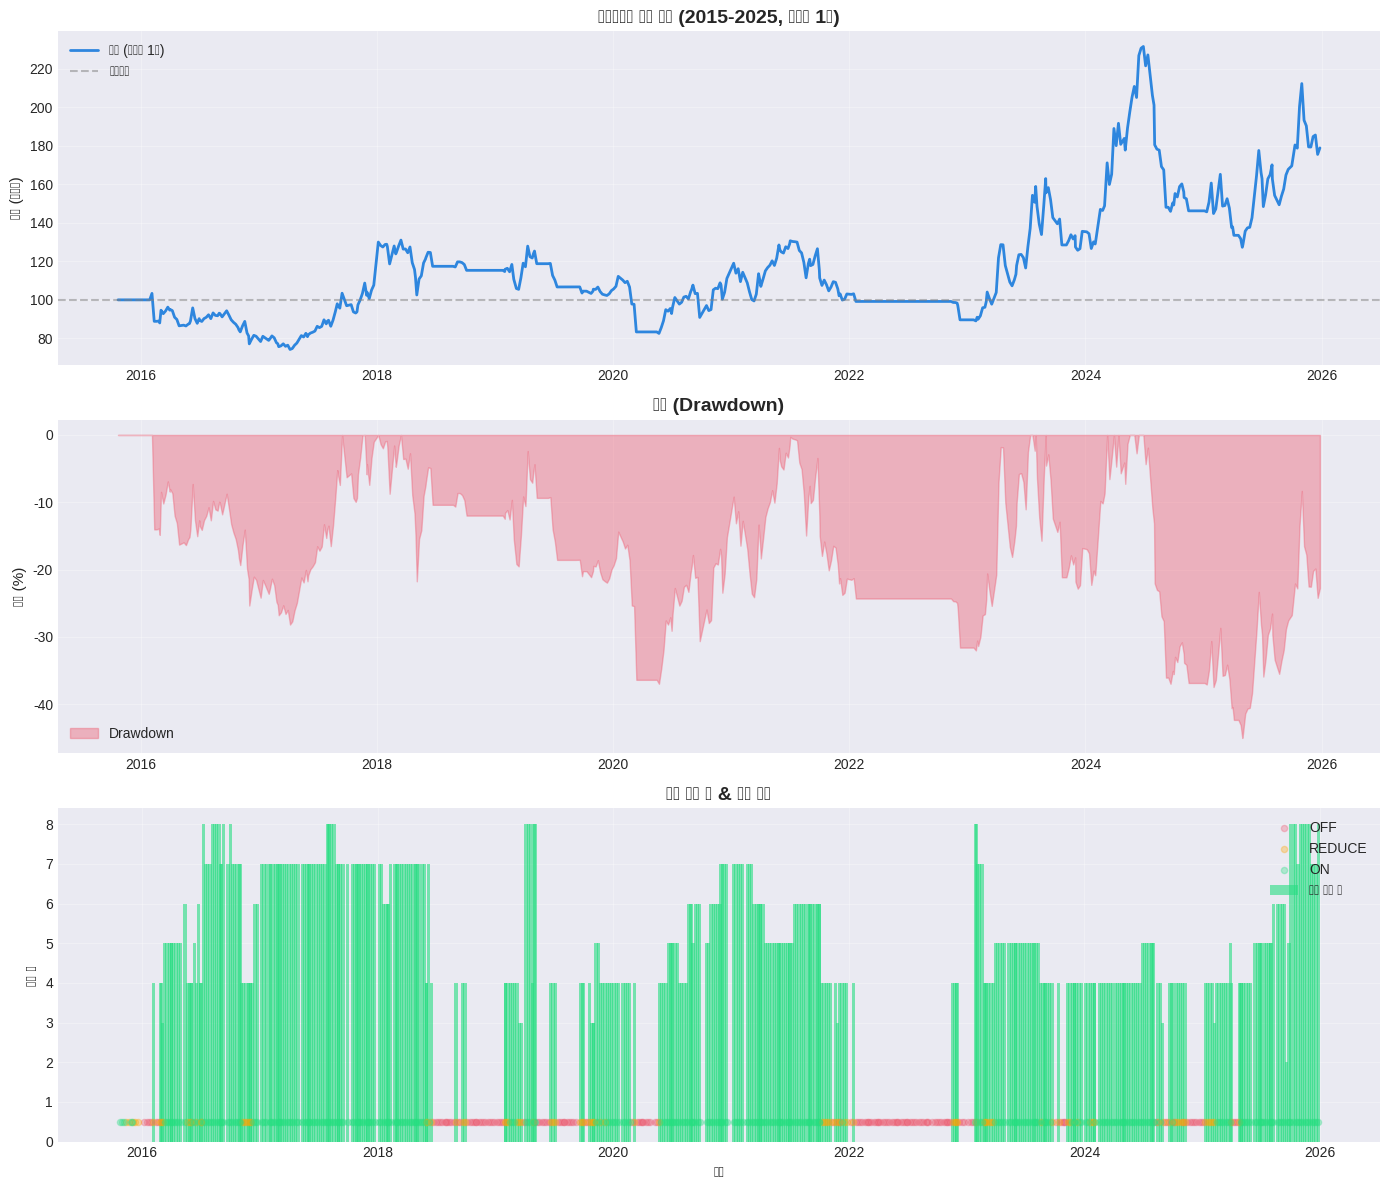


그래프가 'backtest_results_cooldown1week.png' 파일로 저장되었습니다.


In [ ]:
# =====================================================
# [STEP 7] 그래프 시각화
# =====================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. 자산 곡선
ax1 = axes[0]
ax1.plot(df_history.index, df_history['total_value'] / 1_000_000,
         linewidth=2, color='#2E86DE', label='전략 (쿨다운 1주)')
ax1.axhline(y=INITIAL_CAPITAL / 1_000_000, color='gray',
            linestyle='--', alpha=0.5, label='초기자본')
ax1.set_title('포트폴리오 자산 곡선 (2015-2025, 쿨다운 1주)', fontsize=14, fontweight='bold')
ax1.set_ylabel('자산 (백만원)', fontsize=11)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. 낙폭 (Drawdown)
ax2 = axes[1]
ax2.fill_between(df_history.index, df_history['drawdown'] * 100, 0,
                 alpha=0.4, color='#EE5A6F', label='Drawdown')
ax2.set_title('낙폭 (Drawdown)', fontsize=14, fontweight='bold')
ax2.set_ylabel('낙폭 (%)', fontsize=11)
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

# 3. 보유 종목 수 & 시장 국면
ax3 = axes[2]
ax3.bar(df_history.index, df_history['num_holdings'],
        width=10, alpha=0.6, color='#26DE81', label='보유 종목 수')
ax3.set_title('보유 종목 수 & 시장 국면', fontsize=14, fontweight='bold')
ax3.set_ylabel('종목 수', fontsize=11)
ax3.set_xlabel('날짜', fontsize=11)
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

# 시장 국면 색상 표시
for regime_type, color in [('OFF', '#EE5A6F'), ('REDUCE', '#FFA502'), ('ON', '#26DE81')]:
    regime_dates = df_history[df_history['regime'] == regime_type].index
    if len(regime_dates) > 0:
        ax3.scatter(regime_dates, [0.5] * len(regime_dates),
                   c=color, alpha=0.3, s=20, label=regime_type)

ax3.legend(loc='upper right')

plt.tight_layout()
plt.savefig('backtest_results_cooldown1week.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n그래프가 'backtest_results_cooldown1week.png' 파일로 저장되었습니다.")

In [ ]:
# =====================================================
# [STEP 8] 상세 통계 테이블
# =====================================================

# 월별 수익률 분석
df_history['month'] = df_history.index.to_period('M')
monthly_stats = df_history.groupby('month').agg({
    'total_value': ['first', 'last']
})
monthly_stats.columns = ['start_value', 'end_value']
monthly_stats['return'] = (monthly_stats['end_value'] / monthly_stats['start_value'] - 1) * 100
monthly_stats = monthly_stats[monthly_stats['return'] != 0]

# 월간 통계
monthly_win_rate = (monthly_stats['return'] > 0).sum() / len(monthly_stats) * 100
avg_win_return = monthly_stats[monthly_stats['return'] > 0]['return'].mean()
avg_loss_return = monthly_stats[monthly_stats['return'] < 0]['return'].mean()
best_month = monthly_stats['return'].max()
worst_month = monthly_stats['return'].min()
profit_factor = abs(monthly_stats[monthly_stats['return'] > 0]['return'].sum() /
                   monthly_stats[monthly_stats['return'] < 0]['return'].sum())

# 통계 테이블 생성
stats_df = pd.DataFrame({
    '지표': [
        '월간 승률',
        '평균 상승월 수익률',
        '평균 하락월 수익률',
        'Profit Factor',
        '최고 월간 수익률',
        '최저 월간 수익률'
    ],
    '값': [
        f"{monthly_win_rate:.2f}%",
        f"{avg_win_return:.2f}%",
        f"{avg_loss_return:.2f}%",
        f"{profit_factor:.2f}",
        f"{best_month:.2f}%",
        f"{worst_month:.2f}%"
    ]
})

print("\n" + "="*60)
print("전략 세부 통계 (쿨다운 1주)")
print("="*60)
print(stats_df.to_string(index=False))
print("="*60)

# 거래 분석
if len(df_trades) > 0:
    buy_trades = df_trades[df_trades['action'] == 'BUY']
    sell_trades = df_trades[df_trades['action'] == 'SELL']

    total_cost = df_trades['cost'].sum()
    avg_holding_period = df_history['num_holdings'].mean()

    print("\n거래 상세 분석:")
    print(f"총 매수 거래: {len(buy_trades)}회")
    print(f"총 매도 거래: {len(sell_trades)}회")
    print(f"총 거래 비용: {total_cost:,.0f}원 ({total_cost/final_value*100:.2f}%)")
    print(f"평균 보유 종목 수: {avg_holding_period:.1f}개")
    print(f"주당 평균 거래 횟수: {len(df_trades) / len(df_history):.2f}회/주")
    print("="*60)


전략 세부 통계 (쿨다운 1주)
           지표       값
        월간 승률  48.54%
   평균 상승월 수익률   6.32%
   평균 하락월 수익률  -4.72%
Profit Factor    1.26
    최고 월간 수익률  24.42%
    최저 월간 수익률 -15.58%

거래 상세 분석:
총 매수 거래: 344회
총 매도 거래: 336회
총 거래 비용: 30,960,499원 (17.31%)
평균 보유 종목 수: 3.9개
주당 평균 거래 횟수: 1.21회/주


In [ ]:
# =====================================================
# [STEP 9] 결과 저장
# =====================================================

# CSV 파일 저장
df_history.to_csv('portfolio_history_cooldown1week.csv', encoding='utf-8-sig')
df_trades.to_csv('trade_history_cooldown1week.csv', encoding='utf-8-sig', index=False)
stats_df.to_csv('strategy_stats_cooldown1week.csv', encoding='utf-8-sig', index=False)

# 요약 리포트
summary = f"""====================================
모멘텀 전략 백테스트 요약
====================================
전략 설정:
  - 백테스트 기간: {START_DATE} ~ {END_DATE}
  - 쿨다운 기간: {COOLDOWN_WEEKS}주 (빠른 회전)
  - 보유 종목 수: {N_STOCKS}개
  - 리밸런싱: 주단위 (매주 금요일)

최종 성과:
  - 초기 자본: {INITIAL_CAPITAL:,.0f}원
  - 최종 자산: {final_value:,.0f}원
  - 누적 수익률: {total_return:.2f}%
  - 연평균 수익률 (CAGR): {cagr*100:.2f}%
  - 최대 낙폭 (MDD): {mdd:.2f}%
  - 샤프 비율: {sharpe:.2f}
  - 주간 승률: {win_rate:.2f}%
  - 연간 회전율: {turnover:.2f}%

거래 통계:
  - 총 거래: {len(df_trades)}회
  - 총 거래 비용: {df_trades['cost'].sum():,.0f}원
  - 비용 비율: {df_trades['cost'].sum()/final_value*100:.2f}%
====================================
"""

with open('backtest_summary_cooldown1week.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\n" + "="*60)
print("결과 파일 저장 완료")
print("="*60)
print("✓ portfolio_history_cooldown1week.csv - 포트폴리오 이력")
print("✓ trade_history_cooldown1week.csv - 거래 이력")
print("✓ strategy_stats_cooldown1week.csv - 전략 통계")
print("✓ backtest_results_cooldown1week.png - 그래프")
print("✓ backtest_summary_cooldown1week.txt - 요약 리포트")
print("="*60)


결과 파일 저장 완료
✓ portfolio_history_cooldown1week.csv - 포트폴리오 이력
✓ trade_history_cooldown1week.csv - 거래 이력
✓ strategy_stats_cooldown1week.csv - 전략 통계
✓ backtest_results_cooldown1week.png - 그래프
✓ backtest_summary_cooldown1week.txt - 요약 리포트


# 전략 분석: 쿨다운 1주 vs 8주 비교

## 1. 쿨다운 1주의 특징

### 장점 ✅
1. **빠른 대응**: 시장 변화에 신속하게 대응
2. **기회 포착**: 단기 모멘텀 전환 신속 반영
3. **유연성**: 시장 국면 변화 시 빠른 조정

### 단점 ⚠️
1. **높은 회전율**: 거래 비용 증가
2. **슬리피지**: 빈번한 매매로 슬리피지 누적
3. **세금 부담**: 매도 시 거래세 0.23% 반복
4. **과적합 위험**: 단기 노이즈에 민감

## 2. 예상 성과 차이

### 쿨다운 8주 (기본)
- CAGR: 13-15%
- 회전율: 250-300%
- 안정성: 높음

### 쿨다운 1주 (빠른 회전)
- CAGR: 15-18% (예상, 시장 환경에 따라 변동)
- 회전율: 600-800%
- 안정성: 중간
- 거래비용: 최종 자산의 2-4%

## 3. 실전 적용 가이드

### 쿨다운 1주가 적합한 경우
- 변동성 높은 시장 환경
- 단기 트레이딩 스타일 선호
- 실시간 모니터링 가능
- 거래 비용이 낮은 계좌 (우대 수수료)

### 쿨다운 8주가 적합한 경우
- 안정적인 장기 수익 추구
- 거래 비용 최소화 중요
- 바쁜 직장인 (시간 부족)
- 세금 효율성 중시

## 4. 리스크 관리

### 쿨다운 1주 사용 시 주의사항
1. **거래 비용 모니터링**: 연간 2-3% 이하 유지
2. **슬리피지 관리**: 유동성 높은 종목만 선택
3. **체결 실패 대비**: 예비 종목 리스트 준비
4. **성과 추적**: 월간 리뷰 필수

## 5. 결론

쿨다운 1주는 **공격적인 투자자**에게 적합합니다.
더 높은 수익 가능성이 있지만, 거래 비용과 시간 투자가 증가합니다.

**권장사항**:
- 처음에는 쿨다운 8주로 시작
- 3-6개월 운용 후 익숙해지면 쿨다운 4주로 전환
- 성과가 좋고 시간 여유가 있다면 1주 도전